In [123]:
import os
import sys
import anndata as ad
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import metacells as mc
from itertools import combinations

f_dir = os.path.dirname(os.path.abspath("__file__"))  
sys.path.append(os.path.abspath(os.path.join(f_dir, "..", "..", "utils")))

import constants
import utils

import tqdm 
import time

from statsmodels.stats.multitest import multipletests

from scipy.stats import wilcoxon, ks_2samp
from scipy.stats import chi2


%load_ext autoreload
%autoreload 2

sb.set_context("talk")
rng = np.random.default_rng(seed=42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Fig S3A-B

In [124]:
cells_ad = ad.read_h5ad(constants.CELLS_PATH)
metacells_ad = ad.read_h5ad(constants.METACELLS_PATH)
cell_type_colors = pd.read_csv(constants.CELLS_TYPE_COLORS, index_col=0).to_dict()['color']

cd34_positive_cells = ad.read_h5ad(constants.CD34_POSITIVE_CELLS_PATH)

gene_modules_dict = utils.load_pickle(constants.GENE_MODULES_DICT_PATH)

In [125]:
os.makedirs("./output", exist_ok=True)

In [126]:
gene_modules_dict = utils.load_pickle(constants.GENE_MODULES_DICT_PATH)

In [127]:
ds_umis = 2**11

ds_cells_ad = utils.downsample_cells(cd34_positive_cells, target_umis=ds_umis, cut_downsampled=True)
cells_score_df = utils.get_cell_score_per_genes_and_bins(ds_cells_ad, gene_modules_dict)
cells_score_df_fp = (cells_score_df + 1 )/ ds_umis
cells_score_df_lgc = np.log2(cells_score_df_fp)

Downsampling to 2048 UMIs


set unnamed.layers[downsampled]: csr_matrix 4850 X 36497 float32s (6229221 > 0, 3.519%)
set unnamed.uns[downsample_samples]: 2048


Cutting downsampled cells, going to remove 313 cells (6.45%)


In [128]:
cells_score_kmeans = utils.kmeans_with_size(X=cells_score_df_lgc, n_clusters=int(cells_score_df_lgc.shape[0]/50) + 1, size = 50, n_init=50, min_size=12, random_state = 42,max_iter=500)
cells_clusters_series = pd.Series(cells_score_kmeans.labels_.astype(int), index=cells_score_df.index)
cells_for_metacell_based_on_clusters = cd34_positive_cells.copy()
cells_clusters_series_full = pd.Series(-1, index=cells_for_metacell_based_on_clusters.obs_names)
cells_clusters_series_full[cells_clusters_series.index] = cells_clusters_series.values
mc.ut.set_o_data(cells_for_metacell_based_on_clusters, "metacell", cells_clusters_series_full)
clusters_metacells_ad = mc.pl.collect_metacells(cells_for_metacell_based_on_clusters, name='metacells', random_seed=123456)
clusters_metacells_ad = utils.add_gene_modules_summed_score(clusters_metacells_ad, gene_modules_dict,  epsilon = 0, log_base=1, suffix="sum")

set metacells.obs[grouped]: 91 int64s
set metacells.obs[total_umis]: 91 int64s
set metacells.layers[total_umis]: ndarray 91 X 36497 float32s
set metacells.obs[__zeros_downsample_umis]: 91 int64s
set metacells.layers[zeros]: ndarray 91 X 36497 int32s
set unnamed.obs[metacell_name]: 4850 <U8s
set metacells.var[bursty_lonely_gene]: 0 true (0%) out of 36497 bools
set metacells.var[properly_sampled_gene]: 36497 true (100%) out of 36497 bools
set metacells.var[excluded_gene]: 0 true (0%) out of 36497 bools
set metacells.var[noisy_gene]: 44 true (0.1206%) out of 36497 bools
set metacells.var[lateral_gene]: 1284 true (3.518%) out of 36497 bools
set metacells.var[selected_gene]: 219 true (0.6%) out of 36497 bools
set metacells.var[rare_gene]: 0 true (0%) out of 36497 bools
set metacells.var[rare_gene_module]: 36497 int32s
set metacells.obs[metacells_rare_gene_module]: 91 int32s
set metacells.obs[rare_metacell]: 0 true (0%) out of 91 bools
set metacells.uns[outliers]: 313
set metacells.uns[metac

In [129]:
clusters_metacells_ad = utils.add_gene_modules_summed_score(clusters_metacells_ad, gene_modules_dict,  epsilon = 0, log_base=1, suffix="sum")
metacells_ad = utils.add_gene_modules_summed_score(metacells_ad, gene_modules_dict,  epsilon = 0, log_base=1, suffix="sum")

genes_columns = [i for i in clusters_metacells_ad.obs.columns if "_sum" in i]

clusters_metacells_obj_gm = clusters_metacells_ad.obs[genes_columns]
metacells_obj_gm = metacells_ad.obs[genes_columns]

set metacells.obs[baso_dec_post_0_score_sum]: 91 float32s
set metacells.obs[baso_inc_post_0_score_sum]: 91 float32s
set metacells.obs[baso_dec_post_1_score_sum]: 91 float32s
set metacells.obs[baso_inc_post_1_score_sum]: 91 float32s
set metacells.obs[baso_dec_post_2_score_sum]: 91 float32s
set metacells.obs[baso_inc_post_2_score_sum]: 91 float32s
set metacells.obs[baso_dec_post_3_score_sum]: 91 float32s
set metacells.obs[baso_inc_post_3_score_sum]: 91 float32s
set metacells.obs[baso_dec_post_4_score_sum]: 91 float32s
set metacells.obs[baso_inc_post_4_score_sum]: 91 float32s
set metacells.obs[baso_dec_post_5_score_sum]: 91 float32s
set metacells.obs[baso_inc_post_5_score_sum]: 91 float32s
set metacells.obs[baso_dec_post_6_score_sum]: 91 float32s
set metacells.obs[baso_inc_post_6_score_sum]: 91 float32s
set metacells.obs[mast_dec_post_0_score_sum]: 91 float32s
set metacells.obs[mast_inc_post_0_score_sum]: 91 float32s
set metacells.obs[mast_dec_post_1_score_sum]: 91 float32s
set metacells.

In [130]:
bulk_sharpening_corr_mc = utils.get_correlation_between_two_df(clusters_metacells_obj_gm, metacells_obj_gm)
top_correlation_per_bulk_mc = utils.get_n_largest_columns_in_df(bulk_sharpening_corr_mc, 1, row_based=True)
top_correlation_per_bulk_mc = top_correlation_per_bulk_mc[0]
cells_for_metacell_based_on_clusters = mc.ut.slice(cells_for_metacell_based_on_clusters, obs=cells_for_metacell_based_on_clusters.obs.metacell_name !="Outliers")

mc.ut.set_o_data(clusters_metacells_ad, "most_correlated_mc", top_correlation_per_bulk_mc)
mc.ut.set_o_data(cells_for_metacell_based_on_clusters, "most_correlated_mc", clusters_metacells_ad.obs.loc[cells_for_metacell_based_on_clusters.obs.metacell_name, "most_correlated_mc"].values)
mc.ut.set_o_data(cells_for_metacell_based_on_clusters, "most_correlated_mc_type", metacells_ad[cells_for_metacell_based_on_clusters.obs.most_correlated_mc].obs.type.values)
mc.ut.set_o_data(cells_for_metacell_based_on_clusters, "most_correlated_mc_x", metacells_ad.obs.x[cells_for_metacell_based_on_clusters.obs.most_correlated_mc].values)
mc.ut.set_o_data(cells_for_metacell_based_on_clusters, "most_correlated_mc_y", metacells_ad.obs.y[cells_for_metacell_based_on_clusters.obs.most_correlated_mc].values)

set metacells.obs[most_correlated_mc]: 91 objects
set unnamed.obs[most_correlated_mc]: 4537 objects
set unnamed.obs[most_correlated_mc_type]: 4537 objects
set unnamed.obs[most_correlated_mc_x]: 4537 float64s
set unnamed.obs[most_correlated_mc_y]: 4537 float64s


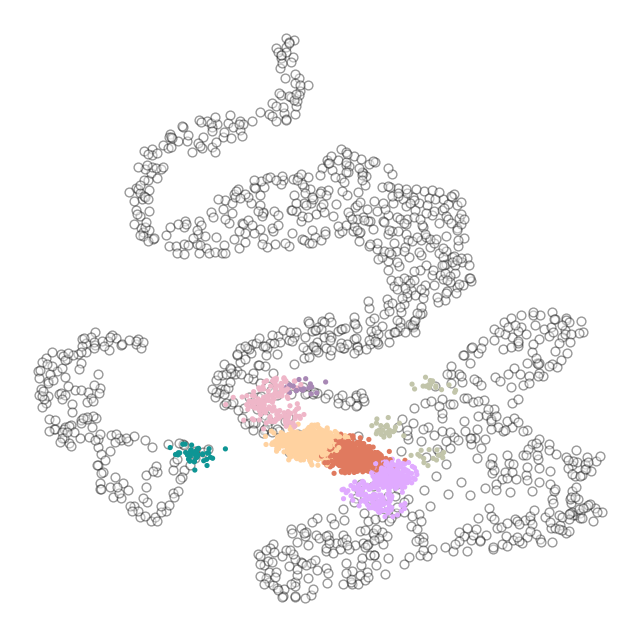

In [131]:
plt.figure(figsize=(8,8))
ax = sb.scatterplot(data=metacells_ad.obs, x="x",y="y", c="white", legend=False,s=40, edgecolor="black", linewidth=1, alpha=0.4)
utils.jitter(cells_for_metacell_based_on_clusters.obs.most_correlated_mc_x.astype(float), cells_for_metacell_based_on_clusters.obs.most_correlated_mc_y.astype(float), 
                     s=5, 
                     c=[cell_type_colors[i] for i in cells_for_metacell_based_on_clusters.obs.most_correlated_mc_type], 
                     jitter_size=0.04)


plt.xticks([])
plt.yticks([])
plt.xlabel("")
plt.ylabel("")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.savefig(os.path.join("./output", "S3A.pdf"), dpi=1200, format="pdf", bbox_inches="tight")

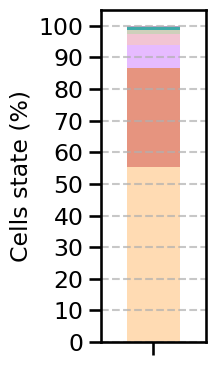

In [132]:
df  = cells_for_metacell_based_on_clusters.obs.most_correlated_mc_type.value_counts() / cells_for_metacell_based_on_clusters.shape[0] * 100
df = df.to_frame().T  # Transpose to make it a 1-row DataFrame

# # Optional: name the index so it shows up on x-axis
df.index = [""]

# # Plot
df.plot(kind="bar", stacked=True, color=[cell_type_colors[c] for c in df.columns], figsize=(2.5, 4) , alpha=0.8)

plt.ylabel("Cells state (%)", fontsize=17)
plt.xlabel("", fontsize=17)
# plt.title("Stacked barplot for one sample")
plt.xticks(rotation=0, fontsize=17)
plt.legend().remove()

plt.yticks(np.arange(0, 101, 10), fontsize=17)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join("./output", "S3B.pdf"), dpi=300)
plt.show()

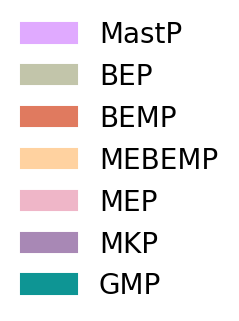

In [133]:
cell_types_seen = ["MEBEMP","BEMP",'MEP', "MastP","BEP",'MKP',"GMP"]
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in cell_types_seen}, ncol=1, output_path=os.path.join("./output", "S3A_legend.pdf"))
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in cell_types_seen}, ncol=1)

In [134]:
df.T

,
most_correlated_mc_type,
MEBEMP,55.499229
BEMP,31.143928
MastP,7.141283
MEP,3.592682
BEP,1.256337
GMP,0.925722
MKP,0.440820


# Fig S3C-D

In [135]:
circulating_cd34_pbmc = ad.read_h5ad(constants.CD34_POSITIVE_PB_METACELLS_PATH)

In [136]:
circulating_cd34_pbmc_type_percentages = circulating_cd34_pbmc.obs.groupby("type")["grouped"].sum()/ circulating_cd34_pbmc.obs["grouped"].sum()* 100
circulating_cd34_pbmc_type_percentages = circulating_cd34_pbmc_type_percentages.to_frame().T

/tmp/ipykernel_1003418/1080137418.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  circulating_cd34_pbmc_type_percentages = circulating_cd34_pbmc.obs.groupby("type")["grouped"].sum()/ circulating_cd34_pbmc.obs["grouped"].sum()* 100


In [137]:
cell_type_colors = pd.read_csv(constants.CD34_POSITIVE_PB_METACELLS_COLROS_PATH, index_col=0).to_dict()['color']

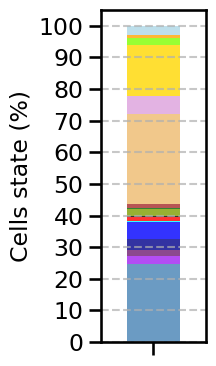

In [138]:
df = circulating_cd34_pbmc_type_percentages
df.index = [""]
# # Plot
df.plot(kind="bar", stacked=True, color=[cell_type_colors[c] for c in df.columns], figsize=(2.5, 4) , alpha=0.8)

plt.ylabel("Cells state (%)", fontsize=17)
plt.xlabel("", fontsize=17)
plt.xticks(rotation=0, fontsize=17)
plt.legend().remove()


plt.yticks(np.arange(0, 101, 10), fontsize=17)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join("./output", "S3D.pdf"), dpi=300)
plt.show()

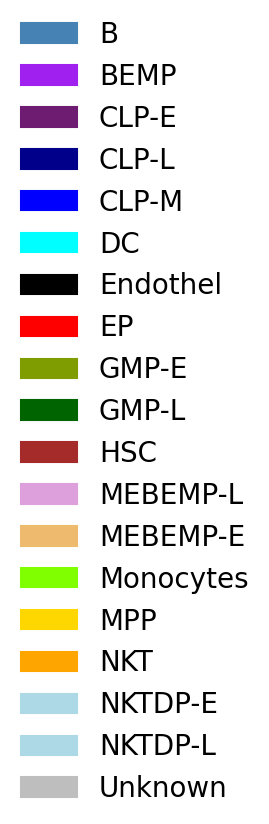

In [139]:
cell_types_seen = df.columns
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in cell_types_seen}, ncol=1, output_path=os.path.join("./output", "S3D_legend.pdf"))
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in cell_types_seen}, ncol=1)

In [140]:
cd34_positive_cultured_metacells_day0 = ad.read_h5ad(constants.HUMAN_CD34_POSITIVE_CULTURED_METACELLS_DAY0_PATH)

In [141]:
cd34_positive_cultured_metacells_day0_type_percentages = cd34_positive_cultured_metacells_day0.obs.groupby("type")["grouped"].sum()/ cd34_positive_cultured_metacells_day0.obs["grouped"].sum()* 100
cd34_positive_cultured_metacells_day0_type_percentages = cd34_positive_cultured_metacells_day0_type_percentages.to_frame().T

/tmp/ipykernel_1003418/4153019722.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cd34_positive_cultured_metacells_day0_type_percentages = cd34_positive_cultured_metacells_day0.obs.groupby("type")["grouped"].sum()/ cd34_positive_cultured_metacells_day0.obs["grouped"].sum()* 100


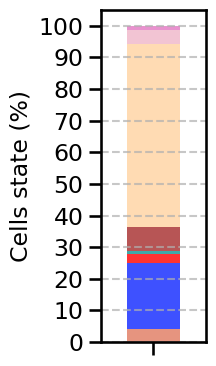

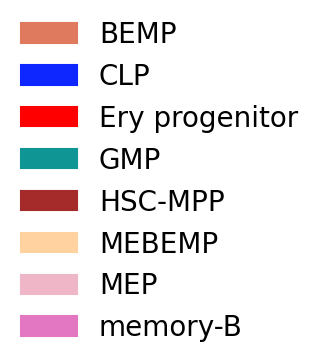

In [142]:
cell_type_dict = {
    'MEBEMP': '#FFD2A0',
    'CLP': "#0e26ff",
    'HSC-MPP': 'brown',
    'Ery progenitor': 'red',
    'MEP': '#EFB6C8',
    'BEMP': '#E07A5F',
    'memory-B': '#e377c2',
    'GMP': '#0E9594'
}

cell_type_dict = {c: cell_type_dict[c] for c in cd34_positive_cultured_metacells_day0_type_percentages.columns}

df = cd34_positive_cultured_metacells_day0_type_percentages
df.index = [""]

# # Plot
df.plot(kind="bar", stacked=True, color=[cell_type_dict[c] for c in df.columns], figsize=(2.5, 4) , alpha=0.8)

plt.ylabel("Cells state (%)", fontsize=17)
plt.xlabel("", fontsize=17)
# plt.title("Stacked barplot for one sample")
plt.xticks(rotation=0, fontsize=17)
plt.legend().remove()

plt.yticks(np.arange(0, 101, 10), fontsize=17)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join("./output", "S3C.pdf"), dpi=300)
plt.show()

utils.plot_generic_dict_of_colors(cell_type_dict, ncol=1, output_path=os.path.join("./output", "S3C_legend.pdf"))
utils.plot_generic_dict_of_colors(cell_type_dict, ncol=1)